# 02 - MiniCNN 基线模型训练

模型：MiniCNN（3层卷积，~50K参数）
目标：建立性能基线，验证数据pipeline正确性

控制方式：
- **开始训练**: 运行下方训练Cell
- **暂停训练**: 点击 Jupyter 停止按钮(■)，断点自动保存
- **继续训练**: 运行下方Checkpoint选择Cell，选择断点后运行训练Cell

In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from pathlib import Path

from training.trainer import (
    PROJECT_ROOT, load_config, set_seed, Trainer,
)
from data.dataloader import create_dataloaders
from training.checkpoint import select_checkpoint_widget
from models.mini_cnn import MiniCNN

# 加载配置
config = load_config()
set_seed(config['seed'])

MODEL_NAME = 'mini_cnn'
model_config = config['models'][MODEL_NAME]
CLASS_NAMES = config['data']['class_names']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 激活函数
activation = model_config.get('activation', config['training']['activation'])

print(f"设备: {device}")
print(f"模型: {MODEL_NAME} | 激活函数: {activation}")
print(f"配置: {model_config}")

设备: cuda
模型: mini_cnn | 激活函数: relu
配置: {'learning_rate': 0.0005, 'batch_size': 256, 'num_epochs': 30, 'dropout': 0.3, 'activation': 'relu'}


## 1. Checkpoint 选择（继续训练时使用）

In [ ]:
# 选择 Checkpoint，点击「确认选择」后运行下一个 Cell
# 选择结果会自动写入 RESUME_FROM 变量
select_checkpoint_widget(MODEL_NAME)

## 2. 准备数据 & 构建模型

In [3]:
# RESUME_FROM 由上方 checkpoint 选择控件自动设置
# - 选了 checkpoint → 自动恢复训练
# - 选了「从头开始训练」→ RESUME_FROM = None
# 如需手动覆盖: RESUME_FROM = None  (或指定路径)

RESUME_FROM = globals().get('RESUME_FROM', None)

if RESUME_FROM:
    meta = Trainer.load_checkpoint_metadata(RESUME_FROM)
    print(f"恢复训练: {RESUME_FROM.name}")
    if meta:
        print(f"  epoch={meta['epoch']}  val_acc={meta['val_acc']:.4f}  best_val_acc={meta['best_val_acc']:.4f}")
else:
    print("从头开始训练")

# 创建数据加载器
train_loader, val_loader, test_loader, _ = create_dataloaders(config, MODEL_NAME)
print(f"训练集: {len(train_loader.dataset)}, 验证集: {len(val_loader.dataset)}, 测试集: {len(test_loader.dataset)}")

# 构建模型
model = MiniCNN(
    num_classes=config['data']['num_classes'],
    dropout=model_config['dropout'],
    activation=activation,
)

# 构建训练器
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    config=config,
    model_name=MODEL_NAME,
    device=device,
    
)

# 恢复 checkpoint
if RESUME_FROM:
    trainer.load_checkpoint(RESUME_FROM)

print(f"总参数量: {trainer.total_params:,}")

从头开始训练
DataLoader: batch_size=256, train_workers=4(prefetch=6), eval_workers=0, pin_memory=True
  class_balanced_sampling: enabled (min_weight=0.5684, max_weight=9.4066, ratio=16.5x)
训练集: 28709, 验证集: 3589, 测试集: 3589
总参数量: 1,274,823


## 3. 性能诊断（可选）

> 运行此 Cell 检查训练速度是否正常。如果速度异常低，会自动给出建议。

In [4]:
# 性能诊断：逐步计时，定位瓶颈
# 正常速度应在 50+ it/s，低于 10 it/s 说明有瓶颈
timings = trainer.diagnose(num_steps=5)


🔍 性能诊断 | 3 步预热 + 5 步采样 | 设备: cuda
   AMP: True | Compile: False
   cudnn.benchmark: True
   cudnn.deterministic: False
   float32_matmul_precision: high
   batch_size: 256
   GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
   预热 1/3: 3631ms
   预热 2/3: 11ms
   预热 3/3: 10ms

阶段              平均(ms)       最小(ms)       最大(ms)      
---------------------------------------------------
data_load             0.27        0.23        0.30
forward               2.29        2.07        2.75
backward              5.26        5.00        5.80
optimizer             1.47        1.34        1.66
eval (全部)           793.41                           

   预热阶段平均: 1218ms/步 → 采样阶段平均: 9ms/步
   VRAM: 81MB / 354MB peak
---------------------------------------------------
单步总计                  9.29 ms
预估稳态速度          ~108 it/s

💡 诊断建议:
   ✅ 速度正常（108 it/s）



In [4]:
# fit(N) = 本次训练 N 轮（无上限，可反复调用续训）
# 从头训练: fit(60)  |  续训 10 轮: fit(10)
history = trainer.fit(60)


模型: mini_cnn | 参数量: 1,274,823
设备: cuda | AMP: True | Compile: False
   matmul_precision: high
从头训练: 共 60 轮 → 训练至第 60 轮



[Epoch 1 | 本轮 1/60] Train: 1.3233/0.2698 | Val: 1.1592/0.3399 (T5:0.9390) | LR: 0.000500 | 24s | ETA 23m50s *


[Epoch 2 | 本轮 2/60] Train: 1.1215/0.3642 | Val: 1.1407/0.3586 (T5:0.9329) | LR: 0.000499 | 4s | ETA 13m46s *


[Epoch 3 | 本轮 3/60] Train: 1.0420/0.4071 | Val: 1.0012/0.4338 (T5:0.9498) | LR: 0.000495 | 4s | ETA 10m22s *


[Epoch 4 | 本轮 4/60] Train: 0.9999/0.4300 | Val: 0.9165/0.4622 (T5:0.9607) | LR: 0.000488 | 4s | ETA 8m37s *


...

[Epoch 56 | 本轮 56/60] Train: 0.6850/0.5673 | Val: 0.6744/0.5748 (T5:0.9833) | LR: 0.000315 | 4s | ETA 21s *


[Epoch 57 | 本轮 57/60] Train: 0.6844/0.5658 | Val: 0.6580/0.5784 (T5:0.9811) | LR: 0.000302 | 4s | ETA 16s *


[Epoch 58 | 本轮 58/60] Train: 0.6709/0.5727 | Val: 0.6470/0.5779 (T5:0.9855) | LR: 0.000289 | 4s | ETA 10s


[Epoch 59 | 本轮 59/60] Train: 0.6726/0.5711 | Val: 0.6793/0.5706 (T5:0.9824) | LR: 0.000276 | 4s | ETA 5s


[Epoch 60 | 本轮 60/60] Train: 0.6727/0.5747 | Val: 0.6787/0.5684 (T5:0.9830) | LR: 0.000263 | 4s | ETA --

训练完成 | 训练至第 60 轮 | 最优 val_acc: 0.5784 | 总用时: 5m21s
训练历史: D:\emotion_recognition\training\logs\mini_cnn\history.json


## 4. 训练曲线

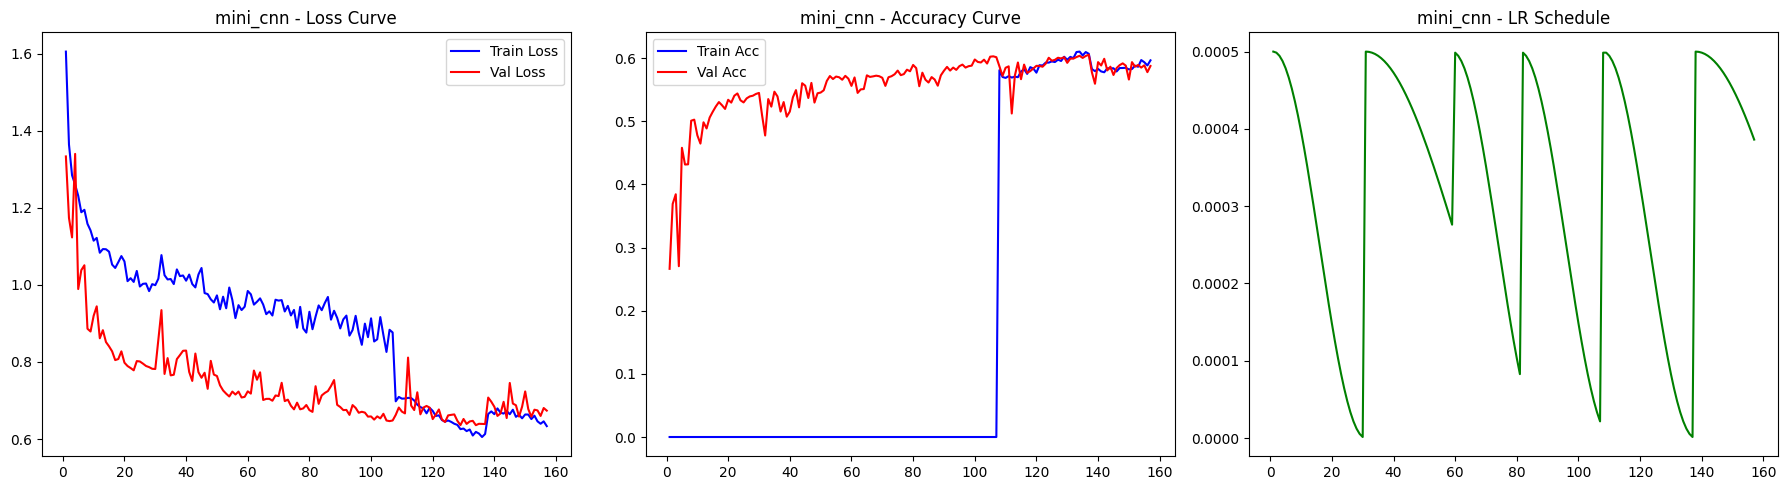

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
axes[0].set_title(f'{MODEL_NAME} - Loss Curve'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
axes[1].set_title(f'{MODEL_NAME} - Accuracy Curve'); axes[1].legend()

axes[2].plot(epochs_range, history['lr'], 'g-')
axes[2].set_title(f'{MODEL_NAME} - LR Schedule')

plt.tight_layout()
curve_dir = PROJECT_ROOT / 'analysis' / 'training_curves'
curve_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(curve_dir / f'{MODEL_NAME}_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 测试集评估

分类报告:
              precision    recall  f1-score   support

       Angry       0.55      0.57      0.56       491
     Disgust       0.63      0.53      0.57        55
        Fear       0.43      0.29      0.35       528
       Happy       0.87      0.83      0.85       879
         Sad       0.48      0.50      0.49       594
    Surprise       0.65      0.81      0.72       416
     Neutral       0.57      0.63      0.60       626

    accuracy                           0.62      3589
   macro avg       0.59      0.59      0.59      3589
weighted avg       0.61      0.62      0.61      3589



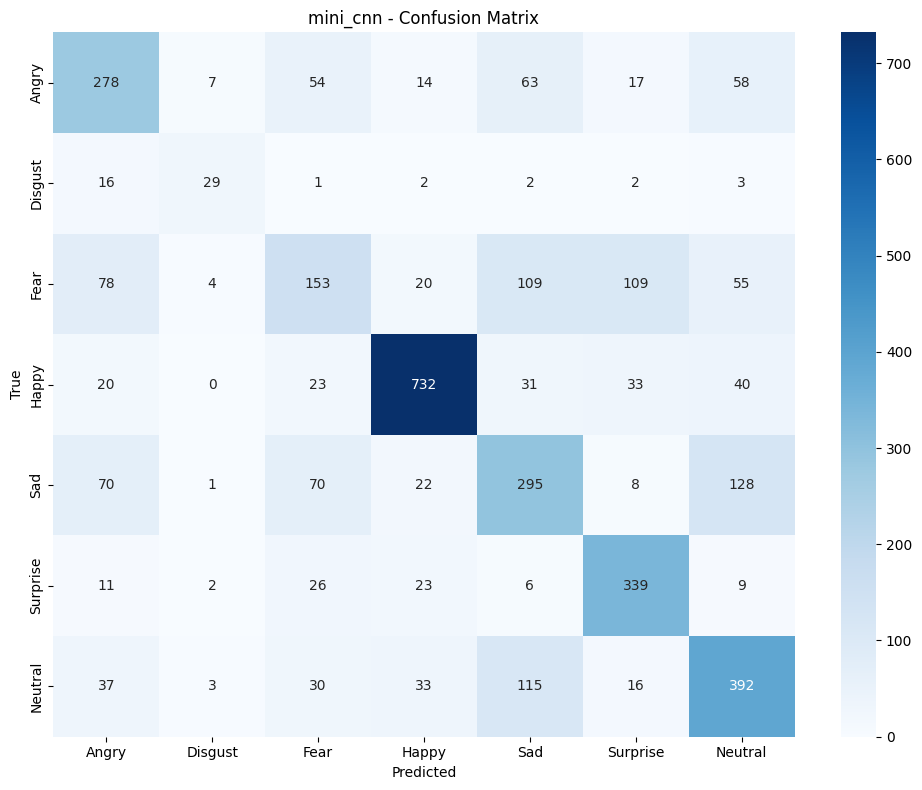

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 加载全局最优模型（跨会话最佳），回退到本轮最佳
if trainer.global_best_model_state:
    trainer.model.load_state_dict(trainer.global_best_model_state)
elif trainer.best_model_state:
    trainer.model.load_state_dict(trainer.best_model_state)
trainer.model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = trainer.model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("分类报告:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

# 混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'{MODEL_NAME} - Confusion Matrix')
plt.tight_layout()
cm_dir = PROJECT_ROOT / 'analysis' / 'confusion_matrices'
cm_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_dir / f'{MODEL_NAME}_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC 曲线

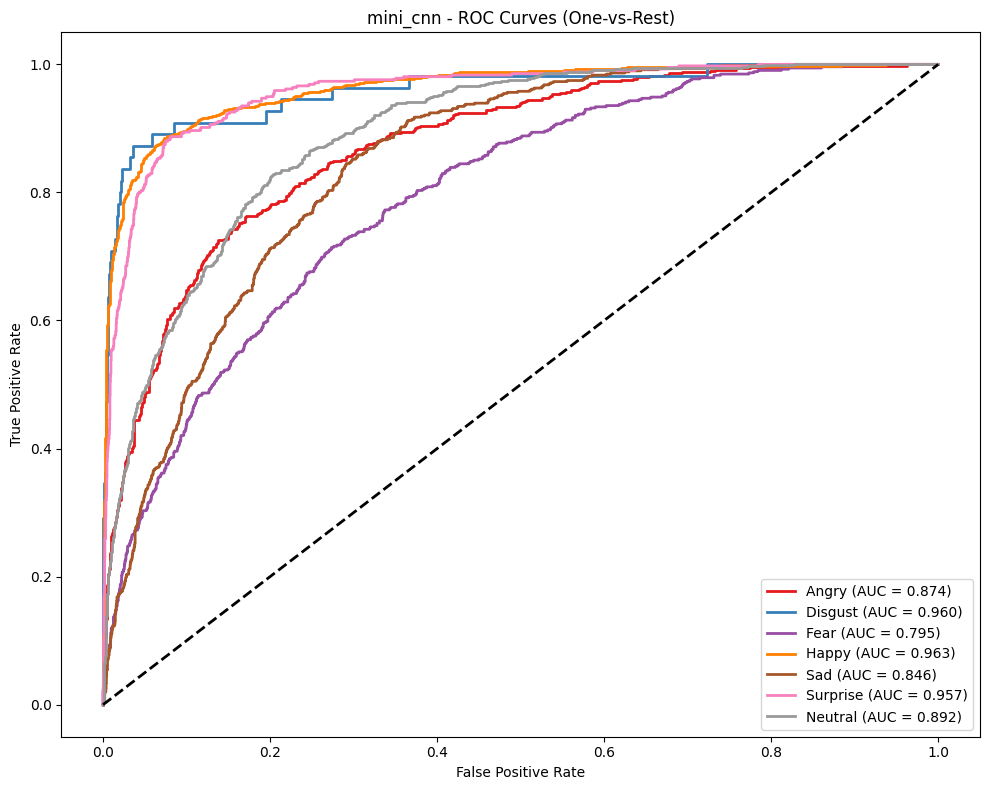

In [7]:
# ROC曲线 - 依赖第5节测试评估产生的 all_labels 和 all_probs
# 如果报NameError，请先运行第5节(测试集评估Cell)
if "all_labels" not in dir() or len(all_labels) == 0:
    raise RuntimeError("请先运行第5节的测试集评估Cell，生成all_labels和all_probs后再运行此Cell")

y_true_bin = label_binarize(all_labels, classes=list(range(len(CLASS_NAMES))))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set1(np.linspace(0, 1, len(CLASS_NAMES)))

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=2)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"{MODEL_NAME} - ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right")
plt.tight_layout()
roc_dir = PROJECT_ROOT / "analysis" / "roc_curves"
roc_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(roc_dir / f"{MODEL_NAME}_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 导出最终模型到推理目录

In [10]:
src = PROJECT_ROOT / 'training' / 'checkpoints' / MODEL_NAME / 'global_best.pth'
dst = PROJECT_ROOT / 'inference' / 'saved_models' / f'{MODEL_NAME}_best.pth'
dst.parent.mkdir(parents=True, exist_ok=True)

if src.exists():
    shutil.copy2(src, dst)
    print(f"模型已复制: {src} -> {dst}")
else:
    print(f"警告: 最优模型不存在 {src}")

模型已复制: D:\emotion_recognition\training\checkpoints\mini_cnn\global_best.pth -> D:\emotion_recognition\inference\saved_models\mini_cnn_best.pth


## 8. 一键导出分析图表到 analysis_saved/

In [8]:
# 将从 §4-6 生成的训练曲线、混淆矩阵、ROC 曲线复制到
# analysis_saved/{MODEL_NAME}_{时间戳}/，文件保持原名

from datetime import datetime

export_root = PROJECT_ROOT / 'analysis_saved'
export_root.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
export_dir = export_root / f'{MODEL_NAME}_{ts}'
export_dir.mkdir(parents=True, exist_ok=True)

# 源文件路径
sources = [
    PROJECT_ROOT / 'analysis' / 'training_curves' / f'{MODEL_NAME}_training_curves.png',
    PROJECT_ROOT / 'analysis' / 'confusion_matrices' / f'{MODEL_NAME}_cm.png',
    PROJECT_ROOT / 'analysis' / 'roc_curves' / f'{MODEL_NAME}_roc.png',
]

copied = 0
for src in sources:
    if src.exists():
        shutil.copy2(src, export_dir)
        copied += 1
        print(f'✅ 已复制: {src.name}')
    else:
        print(f'⚠️ 未找到: {src.name}')

print(f'\n共导出 {copied}/3 张图到: {export_dir}')

✅ 已复制: mini_cnn_training_curves.png
✅ 已复制: mini_cnn_cm.png
✅ 已复制: mini_cnn_roc.png

共导出 3/3 张图到: D:\emotion_recognition\analysis_saved\mini_cnn_20260519_221006
